<a href="https://colab.research.google.com/github/kyle-cech/Homework_9/blob/main/Homework9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import seaborn
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import matplotlib.pyplot as plt

drive.mount('/content/drive') # create connection to Google Drive
filedir = '/content/drive/MyDrive/'
f = filedir + 'SW_with_AOD.csv'
radiation = pd.read_csv(f) #read in data as radiation

Mounted at /content/drive


69.99932861 0.325057983
5.267974899 0.001963017
16.27 3.08e-05
0.645195663 0.0
6.701678276 0.093588173
488.9841003 190.3525085
1013.25 762.2340698
0.746 0.006
0.724 0.006
1116.736084 0.001666667
842.5145264 0.0


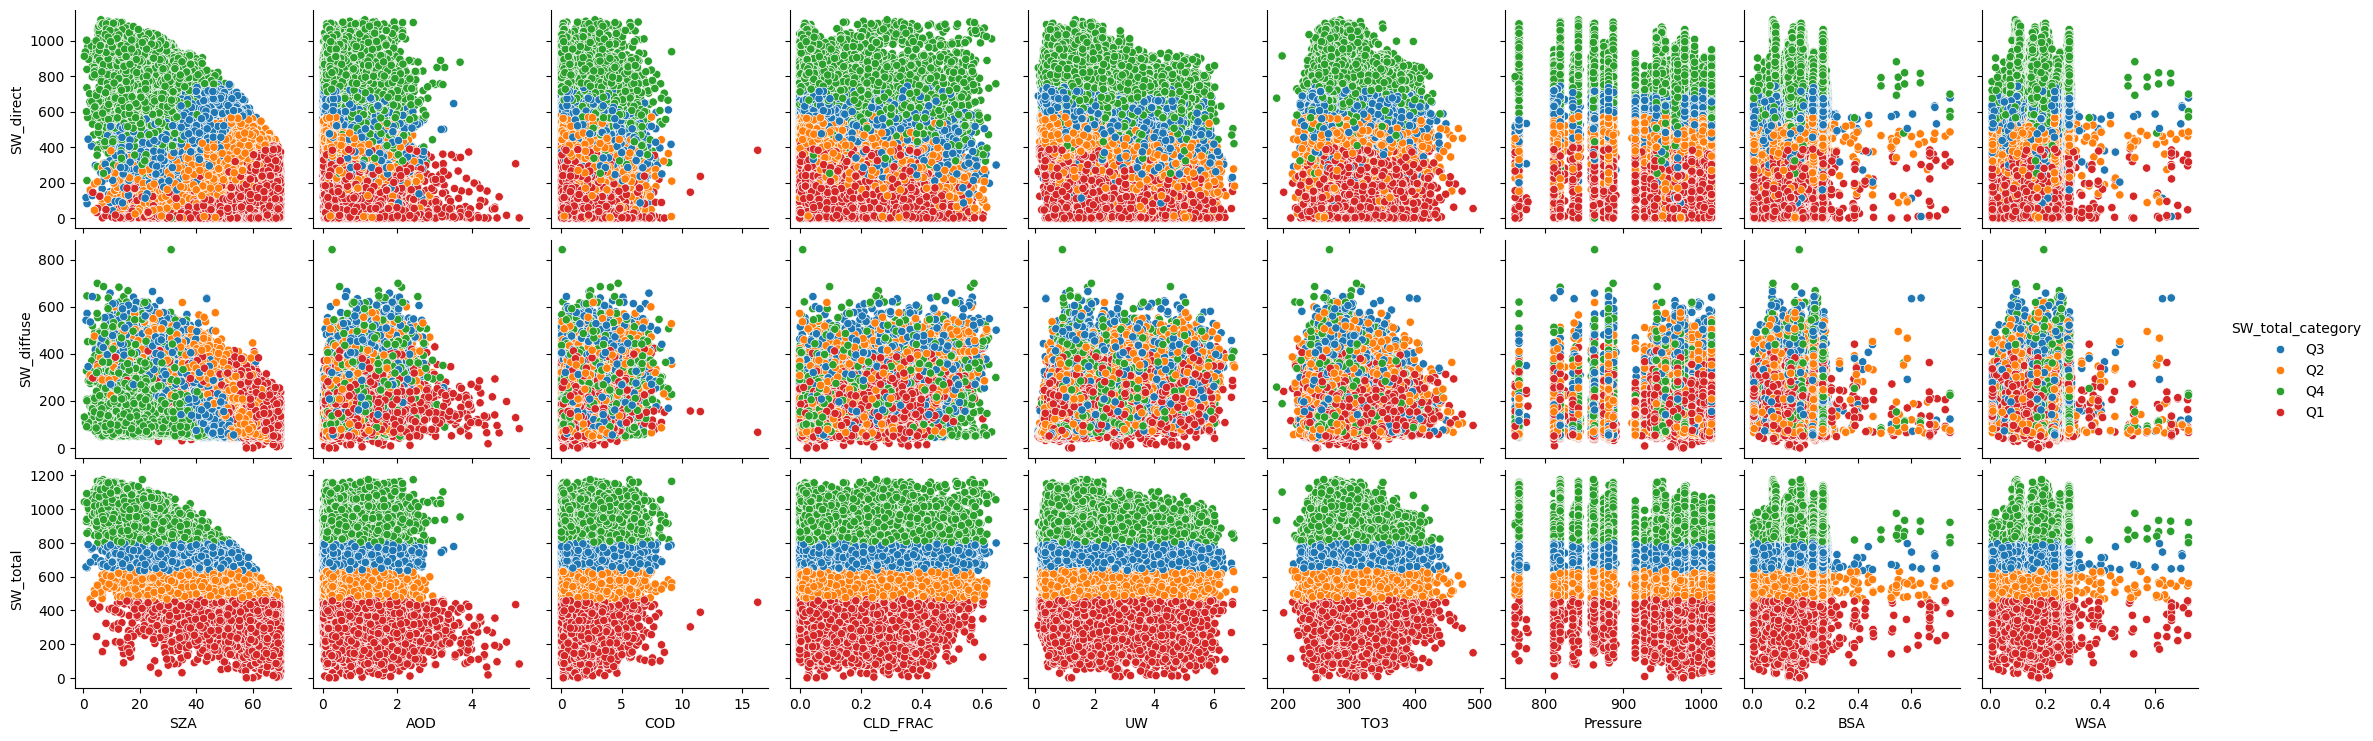

In [ ]:
#Part 1
radiation = radiation.dropna() #get rid of NA values
for i in radiation.columns:
  print(max(radiation[i]), min(radiation[i])) #check max and min for columns to check for unusual values

radiation['SW_total'] = radiation['SW_diffuse'] + radiation['SW_direct'] #create total sw radiation column
q1 = radiation['SW_total'].quantile(.25)
q2 = radiation['SW_total'].quantile(.5)
q3 = radiation['SW_total'].quantile(.75) #make quantiles of total sw radiation for categorization
def categorize(x): #function to categorize based on total sw radiation
  if x <= q1:
    return 'Q1'
  if x <= q2:
    return 'Q2'
  if x <= q3:
    return 'Q3'
  else:
    return 'Q4'

radiation['SW_total_category'] = radiation['SW_total'].apply(categorize) #categorize sw totals

cols = radiation.columns
y = cols[-4:-1] #get response columns
x = cols[:-4] #get feature columns
scaler = preprocessing.MinMaxScaler()
normalized = scaler.fit_transform(radiation[x]) #normalize feature columns
seaborn.pairplot(radiation, hue = 'SW_total_category', x_vars=x, y_vars=y) #plot all feature variables against all response variables

Text(0, 0.5, 'Inertia')

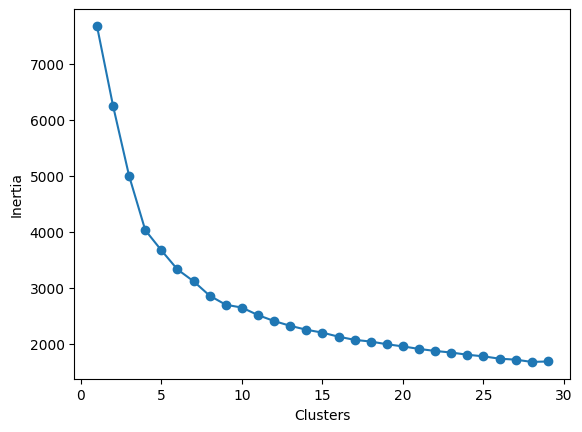

In [ ]:
#Part 2
radiation_normalized = pd.DataFrame(normalized, columns=x) #create new df with normalized data
for i in y:
  radiation_normalized[i] = radiation[i] #add response variables to new df
radiation_normalized['SW_total_categoy'] = radiation['SW_total_category']

X = radiation_normalized[x]
inertia = [] #create empty list for inertias
for i in range(1, 30): #get inertia for kmeans with k being between 1 and 30
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)
plt.plot(range(1, 30), inertia, marker = 'o') #plot inertias
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.title('Inertia From Different K Values')

Text(0, 0.5, 'SZA')

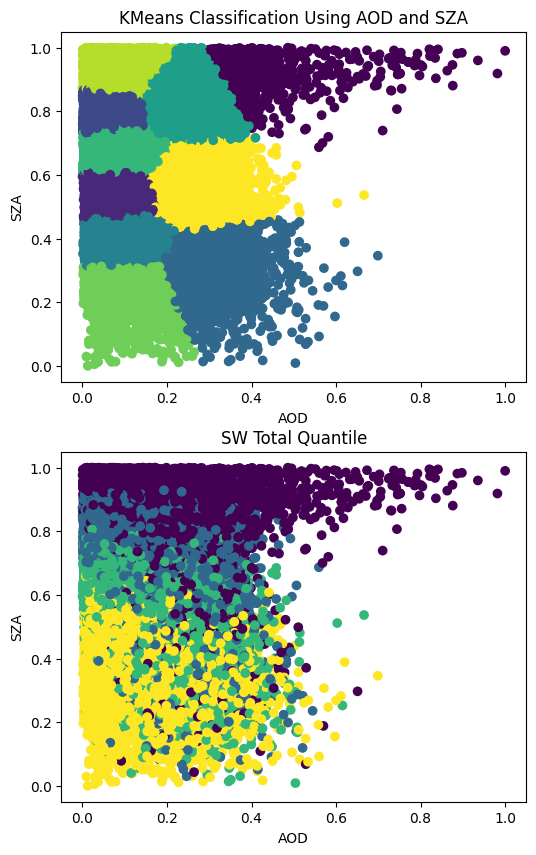

In [ ]:
def num(x): #function to get number from quantile category
  return int(x[-1])
radiation_normalized['category_num'] = radiation_normalized['SW_total_categoy'].apply(num) #create new column with quantile number

kmeans = KMeans(n_clusters=10)
kmeans.fit(radiation_normalized[['AOD', 'SZA']]) #fit kmeans model with k=10
clusters = kmeans.predict(radiation_normalized[['AOD', 'SZA']]) #predict clusters

fig, ax = plt.subplots(2,1, figsize = (6,10)) #plot clusters and sw quantiles for comparing AOD and SZA
ax[0].set_title('KMeans Classification Using AOD and SZA')
ax[0].scatter(radiation_normalized[['AOD']],radiation_normalized[['SZA']] , c = clusters)
ax[0].set_xlabel('AOD')
ax[0].set_ylabel('SZA')
ax[1].set_title('SW Total Quantile')
ax[1].scatter(radiation_normalized[['AOD']],radiation_normalized[['SZA']] , c = radiation_normalized['category_num'].values)
ax[1].set_xlabel('AOD')
ax[1].set_ylabel('SZA')

In [ ]:
"""
The clusters look mostly evenly distributed when plotting their categorization based on SZA and AOD. However, there doesn't seem to be a clear pattern
for their categorization, rather it just divides the dense block of data points into 10 even groups. When looking at the solar radiation categories, it
is apparent that the categories don't match up with the clusters. Most of the clusters correspond to at least 2 different quantiles, and the quantiles
themselves don't show much distinction when comparing their SZA and AOD. The only clear distinction is that the first quantile (purple) has high SZA and
the fourth quantile (yellow) has low SZA and AOD.
"""

"\nThe clusters look mostly evenly distributed when plotting their categorization based on SZA and AOD. However, there doesn't seem to be a clear pattern for their categorization, rather it just divides the dense block of data points into 10 even groups. When looking at the solar radiation categories, it is apparent that the categories don't match up with the clusters. Most of the clusters correspond to at least 2 different quantiles, and the quantiles themselves don't show much distinction when comparing their SZA and AOD. The only clear distinction is that the first quantile (purple) has high SZA and the fourth quantile (yellow) has low SZA and AOD.\n"

Decision Tree RMSE: 136.47450148122044 Decision Tree R2: 0.6088658285122297 Random Forest RMSE: 97.9678194362796 Random Forest R2: 0.7984468407282918


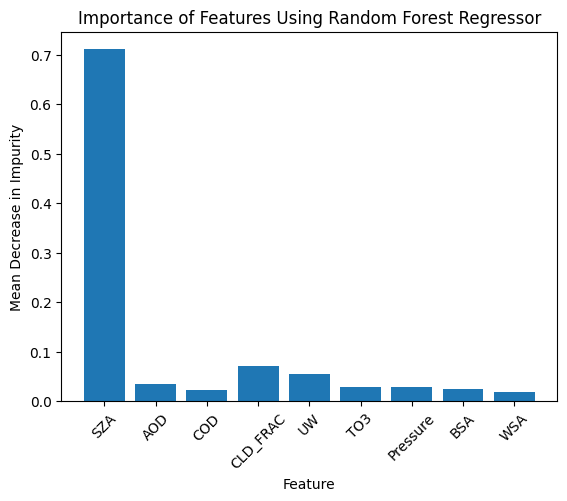

In [ ]:
#Part 3
train_x, test_x, train_y, test_y = train_test_split(X, radiation_normalized['SW_total'], random_state = 7) #make train and test data
tree = DecisionTreeRegressor()
tree.fit(train_x, train_y) #fit decision tree
y_pred_tree = tree.predict(test_x) #make predictions
tree_r2 = metrics.r2_score(test_y, y_pred_tree) #get r2 from tree
tree_rmse = metrics.root_mean_squared_error(test_y, y_pred_tree) #get rmse of tree

forest = RandomForestRegressor()
forest.fit(train_x, train_y) #fit random forest
y_pred_forest = forest.predict(test_x) #predict values for test data
forest_r2 = metrics.r2_score(test_y, y_pred_forest) #get r2 from random forest
forest_rmse = metrics.root_mean_squared_error(test_y, y_pred_forest) #find rmse of forest
importance = forest.feature_importances_ #get feature importances

plt.bar(x, importance) #plot feature importances
plt.xticks(rotation = 45)
plt.xlabel('Feature')
plt.ylabel('Mean Decrease in Impurity')
plt.title('Importance of Features Using Random Forest Regressor')
print('Decision Tree RMSE:', tree_rmse, 'Decision Tree R2:', tree_r2, 'Random Forest RMSE:', forest_rmse, 'Random Forest R2:', forest_r2)

In [ ]:
"""
After graphing the feature importances, it is clear that SZA has the most significance when predicting total shortwave radiation by far. CLD_FRAC and UW
also have some significance when compared to the other variables, but it is still much less than SZA.
"""

'\nAfter graphing the feature importances, it is clear that SZA has the most significance when predicting total shortwave radiation by far. CLD_FRAC and UW also have some significance when compared to the other variables, but it is still much less than SZA.\n'

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
train_x, test_x, train_y, test_y = train_test_split(X, radiation_normalized['SW_total_categoy'])
kn = KNeighborsClassifier()
kn.fit(train_x, train_y) #fit KNeighbors model
kn_pred = kn.predict(test_x) #make predictions with model
print("KNeighbors Confusion Matrix:",metrics.confusion_matrix(test_y, kn_pred))
print("KNeighbors Accuracy:",metrics.accuracy_score(test_y, kn_pred))
print("KNeighbors Precision:",metrics.precision_score(test_y, kn_pred, average='macro'))
print("KNeighbors Recall:",metrics.recall_score(test_y, kn_pred, average='macro'))
print("KNeighbors F1 score:", metrics.f1_score(test_y, kn_pred, average='macro'))

nb = GaussianNB()
nb.fit(train_x, train_y) #fit Gaussian NB model
nb_pred = nb.predict(test_x) #make predictions from model
print("GaussianNB Confusion Matrix:",metrics.confusion_matrix(test_y, nb_pred))
print("GaussianNB Accuracy:",metrics.accuracy_score(test_y, nb_pred))
print("GaussianNB Precision:",metrics.precision_score(test_y, nb_pred, average='macro'))
print("GaussianNB Recall:",metrics.recall_score(test_y, nb_pred, average='macro'))
print("GaussianNB F1 score:", metrics.f1_score(test_y, nb_pred, average='macro'))

KNeighbors Confusion Matrix: [[1636  435   98   50]
 [ 445 1299  392   62]
 [  84  415 1312  375]
 [  19   68  336 1780]]
KNeighbors Accuracy: 0.6844197138314785
KNeighbors Precision: 0.6834618628779563
KNeighbors Recall: 0.6841082348066769
KNeighbors F1 score: 0.6837110626240799
GaussianNB Confusion Matrix: [[1580  448  125   66]
 [ 418 1292  368  120]
 [  45  552 1208  381]
 [   9    6  487 1701]]
GaussianNB Accuracy: 0.6564842153077447
GaussianNB Precision: 0.6585777269478157
GaussianNB Recall: 0.6561439904531229
GaussianNB F1 score: 0.6569662717347287


In [ ]:
"""
The KNeighbors Classifier performed better at classifying the total shortwave radiation category than the Gaussian Naive Bayes model. When calculating
the precision, recall, and F1 score, I averaged out all of the categories' individual scores to get a single metric. But, when comparing the accuracy,
precision, recall, and F1 score, they are all higher from the KNeighbors model by around .03 to .04.
"""

"\nThe KNeighbors Classifier performed better at classifying the total shortwave radiation category than the Gaussian Naive Bayes model. When calculating the precision, recall, and F1 score, I averaged out all of the categories' individual scores to get a single metric. But, when comparing the accuracy, precision, recall, and F1 score, they are all higher from the KNeighbors model by around .03 to .04. \n"

In [ ]:
#Part 4

"""
After analyzing the shortwave radiation with a range of input features, it is clear that the solar zenith angle is the most important when predicting the
total shortwave radiation. The bar plot of their importances shows that it has about seven times as much importance as the second most important feature,
cloud fraction. There aren’t very clear patterns in the clusters or classification groups. The clusters appear to just divide the data points in 10 equal
rectangles, and the classification groups don’t align with these clusters since each cluster has around 2 different classification groups in it. I would
recommend using a random forest regression model to predict solar radiation. The classification models produced results that had low accuracy, precision,
recall, and F1 scores. Also, considering there were only 4 categories with large ranges, these results wouldn't be desirable. And, using decision tree
regression produced a high RMSE and low R2 value. However, the random forest regression had a relatively low RMSE of about 98 and an R2 value of about .8
which was the best performance of all the models.
"""

"\nAfter analyzing the shortwave radiation with a range of input features, it is clear that the solar zenith angle is the most important when predicting the total shortwave radiation. The bar plot of their importances shows that it has about seven times as much importance as the second most important feature, cloud fraction. There aren’t very clear patterns in the clusters or classification groups. The clusters appear to just divide the data points in 10 equal rectangles, and the classification groups don’t align with these clusters since each cluster has around 2 different classification groups in it. I would recommend using a random forest regression model to predict solar radiation. The classification models produced results that had low accuracy, precision, recall, and F1 scores, and using decision tree regression had a high RMSE and low R2 value. Also, considering there were only 4 categories with large ranges, these results wouldn't be desirable. However, the random forest regres